In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

# **Baseline frequencies**

In [2]:
f1 = 0.260958
f2 = 0.314929
f3 = 1.213466
f4 = 1.310806
f5 = 1.505331
f6 = 1.505331

In [3]:
nodes = []
nodal_values = np.loadtxt('../text_files/nodes_minimal_model.txt', delimiter=',')
theta = -13 # degrees

nodal_values[:, 1] = nodal_values[:, 1] * np.cos(np.radians(theta)) - nodal_values[:, 2] * np.sin(np.radians(theta))
nodal_values[:, 2] = nodal_values[:, 1] * np.sin(np.radians(theta)) + nodal_values[:, 2] * np.cos(np.radians(theta))

for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))



# **Primary truss parameters**

In [4]:
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
m = 5596024
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]

print(Aeq / Ieqy)

0.008129475143596973


# **Fenders, connecting elements and retaining wall parameters**

In [5]:
k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender =  mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]

h_eq = 22
Iy_wall = 1250
Iz_wall = 0.25 * Iy_wall
Ip_wall = Iy_wall + Iz_wall
It_wall = 0.05 * Iy_wall
A_wall = Iy_wall * 12 / h_eq**2
m_wall = 6455148
L_wall = 237.5
rho_wall = m_wall / (L_wall * A_wall)
ep_K_wall = [E, G, A_wall, Iy_wall, Iz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_wall, Iy_wall, Iz_wall, Ip_wall]


# **Connecting truss parameters**

In [6]:

A_eq, Iy_eq, Iz_eq, b_eq, h_eq = mat.stiffness_connecting_truss(d1, d2, t1, t2, h_truss, L_truss_element_y)
Ip_connecting_truss = Iy_eq + Iz_eq 
It_eq = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
ep_K_connecting_truss = [E, G, A_eq, Iy_eq, Iz_eq, It_eq, k]
ep_m_connecting_truss = [rho_truss, A_eq, Iy_eq, Iz_eq, Ip_connect]

# **Braces parameters**

In [7]:
k = 5/6
Iy, Iz, Ip, It, A = mat.stiffness_braces()
ep_K_braces = [E, G, A, Iy, Iz, It, k]
ep_m_braces = [rho, A, Iy, Iz, Ip]

# **Senstivity analysis to change in k (axial stiffness locomobile)**

In [8]:
N_loops = 1000
kl_min = 100
kl_max = 1e9
kl = np.arange(kl_min, kl_max, (kl_max - kl_min) / N_loops)



In [9]:
elements = []
element_nodes = np.loadtxt('../text_files/element_nodes_OP3.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m, theta))
    elif element_nodes[i, 2] == 1:
        elements.append(e.elements_added_mass_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall, theta))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect, theta))
    elif element_nodes[i, 2] == 3:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connecting_truss, ep_m_connecting_truss, theta))   
    elif element_nodes[i, 2] == 4:
        elements.append(e.elements_wet(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_braces, ep_m_braces, theta))
    elif element_nodes[i, 2] == 5:
        elements.append(e.elements_added_mass_truss(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m, theta))
element_nodes = element_nodes[:, :2] # Remove the column with element type information



dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))



In [10]:
fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]

k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
kl_dofs = [dofs['dof_129'][0], dofs['dof_129'][1]] 




In [11]:
params = np.zeros((N_loops, 10))
eigvecs_params = np.empty(N_loops, dtype=object)

for i in range(len(kl)):
    N = len(nodes)
    DOFS_per_node = 6

    K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
    M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

    for j in range(len(element_locs)):
        K_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-1]
        M_global[np.ix_(element_locs[j], element_locs[j])] += elements[j][-2]

    K_global = 0.5 * (K_global + K_global.T)
    M_global = 0.5 * (M_global + M_global.T)

    for dof in k_fender_dofs:
        K_global[dof, dof] += k_fender

    for dof in kl_dofs:
        K_global[dof, dof] += kl[i]

    indices_to_remove = np.hstack((dofs['dof_1'][0:3]))
    keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)

    K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
    M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

    eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)

    tol = 1e-6
    positive = eigvals_global > tol
    eigvals_global = eigvals_global[positive]
    eigvecs_global = eigvecs_global[:, positive]

    frequencies_rad = np.sqrt(eigvals_global)
    frequencies_hz = frequencies_rad / (2 * np.pi)
    eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
    params[i, :] = frequencies_hz[:10]
    eigvecs_params[i] = eigvecs_full.copy()

    print('Loop number:', i)


Loop number: 0
Loop number: 1
Loop number: 2
Loop number: 3
Loop number: 4
Loop number: 5
Loop number: 6
Loop number: 7
Loop number: 8
Loop number: 9
Loop number: 10
Loop number: 11
Loop number: 12
Loop number: 13
Loop number: 14
Loop number: 15
Loop number: 16
Loop number: 17
Loop number: 18
Loop number: 19
Loop number: 20
Loop number: 21
Loop number: 22
Loop number: 23
Loop number: 24
Loop number: 25
Loop number: 26
Loop number: 27
Loop number: 28
Loop number: 29
Loop number: 30
Loop number: 31
Loop number: 32
Loop number: 33
Loop number: 34
Loop number: 35
Loop number: 36
Loop number: 37
Loop number: 38
Loop number: 39
Loop number: 40
Loop number: 41
Loop number: 42
Loop number: 43
Loop number: 44
Loop number: 45
Loop number: 46
Loop number: 47
Loop number: 48
Loop number: 49
Loop number: 50
Loop number: 51
Loop number: 52
Loop number: 53
Loop number: 54
Loop number: 55
Loop number: 56
Loop number: 57
Loop number: 58
Loop number: 59
Loop number: 60
Loop number: 61
Loop number: 62
Lo

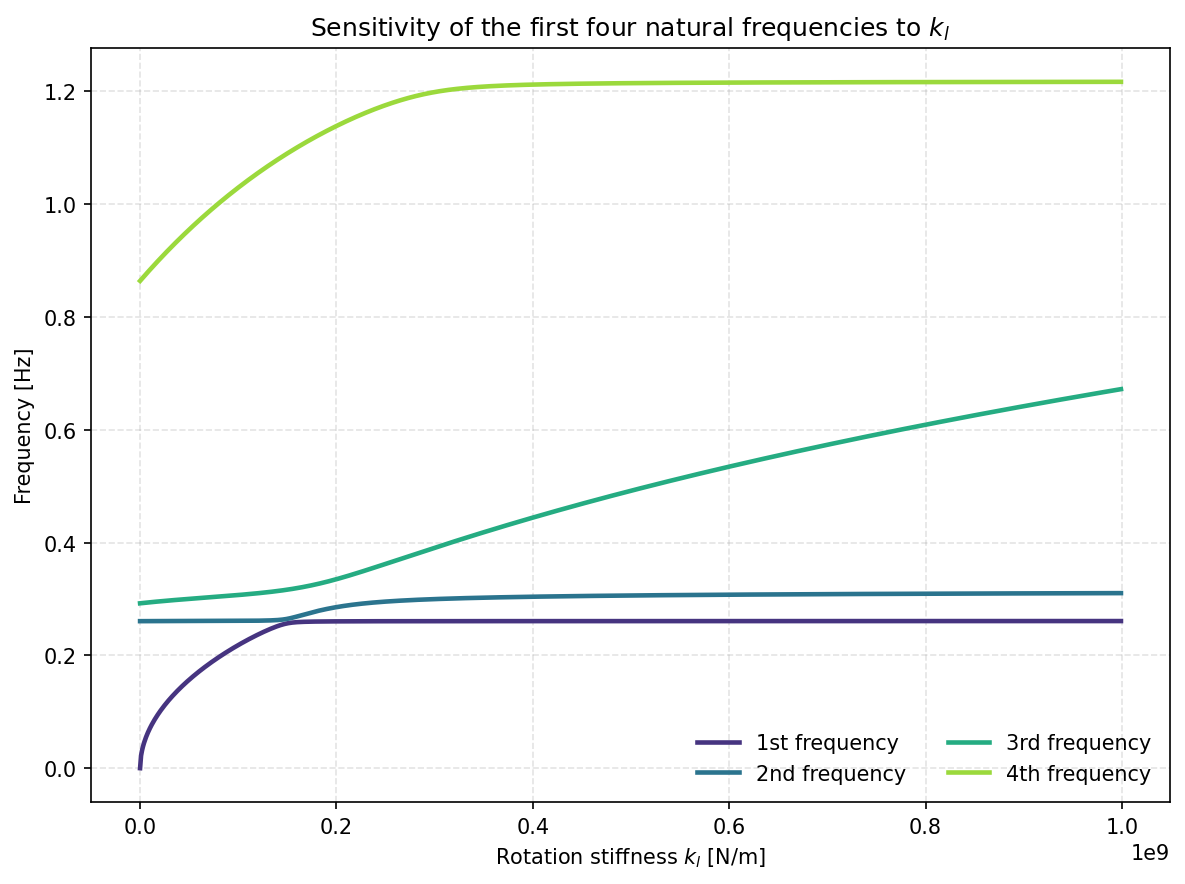

In [12]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

labels = ['1st', '2nd', '3rd', '4th']
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.plot(kl, params[:, i], label=f'{label} frequency', linewidth=2.2, color=color)

ax.set_xlabel(r'Rotation stiffness $k_l$ [N/m]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title('Sensitivity of the first four natural frequencies to $k_l$')
ax.grid(True, which='both', linestyle='--', alpha=0.35)
ax.legend(frameon=False, ncol=2)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.show()

In [13]:
percent_diff_f1 = (f1 - params[:, 0]) / f1 * 100
percent_diff_f2 = (f2 - params[:, 1]) / f2 * 100
percent_diff_f3 = (f3 - params[:, 2]) / f3 * 100
percent_diff_f4 = (f4 - params[:, 3]) / f4 * 100
percent_diff_f5 = (f5 - params[:, 4]) / f5 * 100
percent_diff_f6 = (f6 - params[:, 5]) / f6 * 100

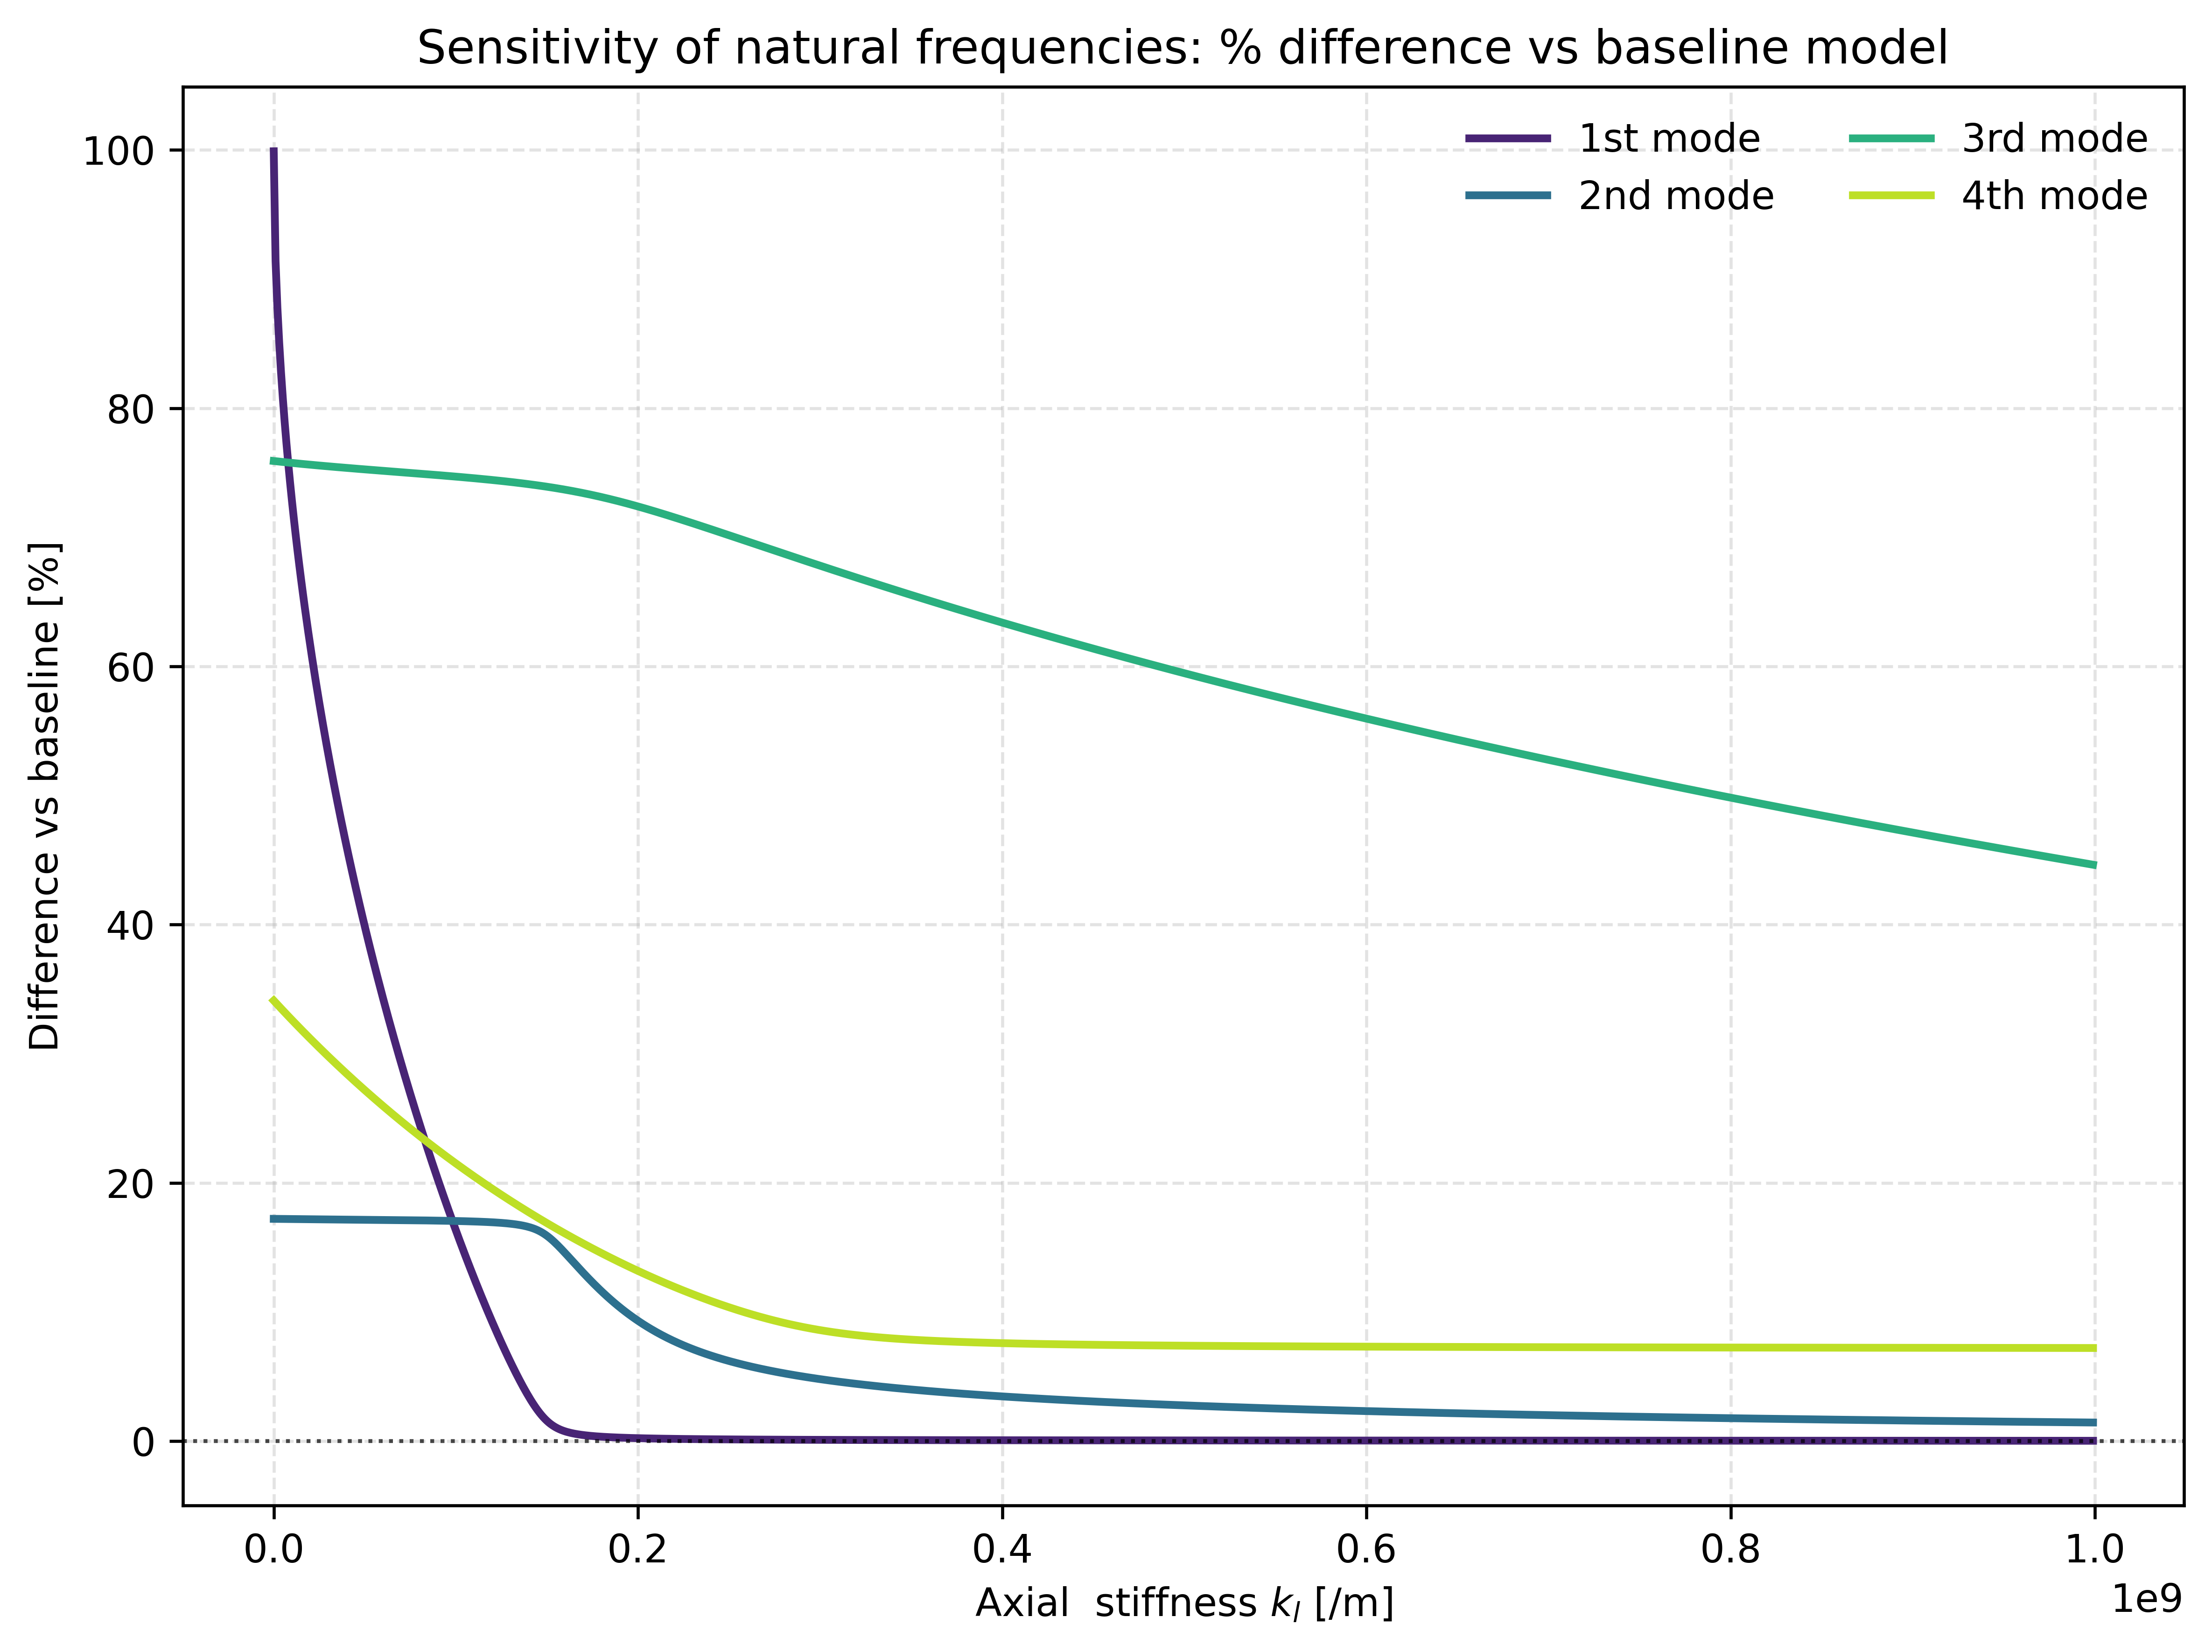

In [14]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

labels = ['1st', '2nd', '3rd', '4th', '5th', '6th']
series = [percent_diff_f1, percent_diff_f2, percent_diff_f3, percent_diff_f4]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(series)))

for y, label, color in zip(series, labels, colors):
    ax.plot(kl, y, label=f'{label} mode', linewidth=2.0, color=color)

ax.axhline(0, color='k', linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel(r'Axial  stiffness $k_l$ [/m]')
ax.set_ylabel('Difference vs baseline [%]')
ax.set_title('Sensitivity of natural frequencies: % difference vs baseline model')
ax.grid(True, which='both', linestyle='--', alpha=0.35)
ax.legend(frameon=False, ncol=2)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

plt.tight_layout()
plt.show()

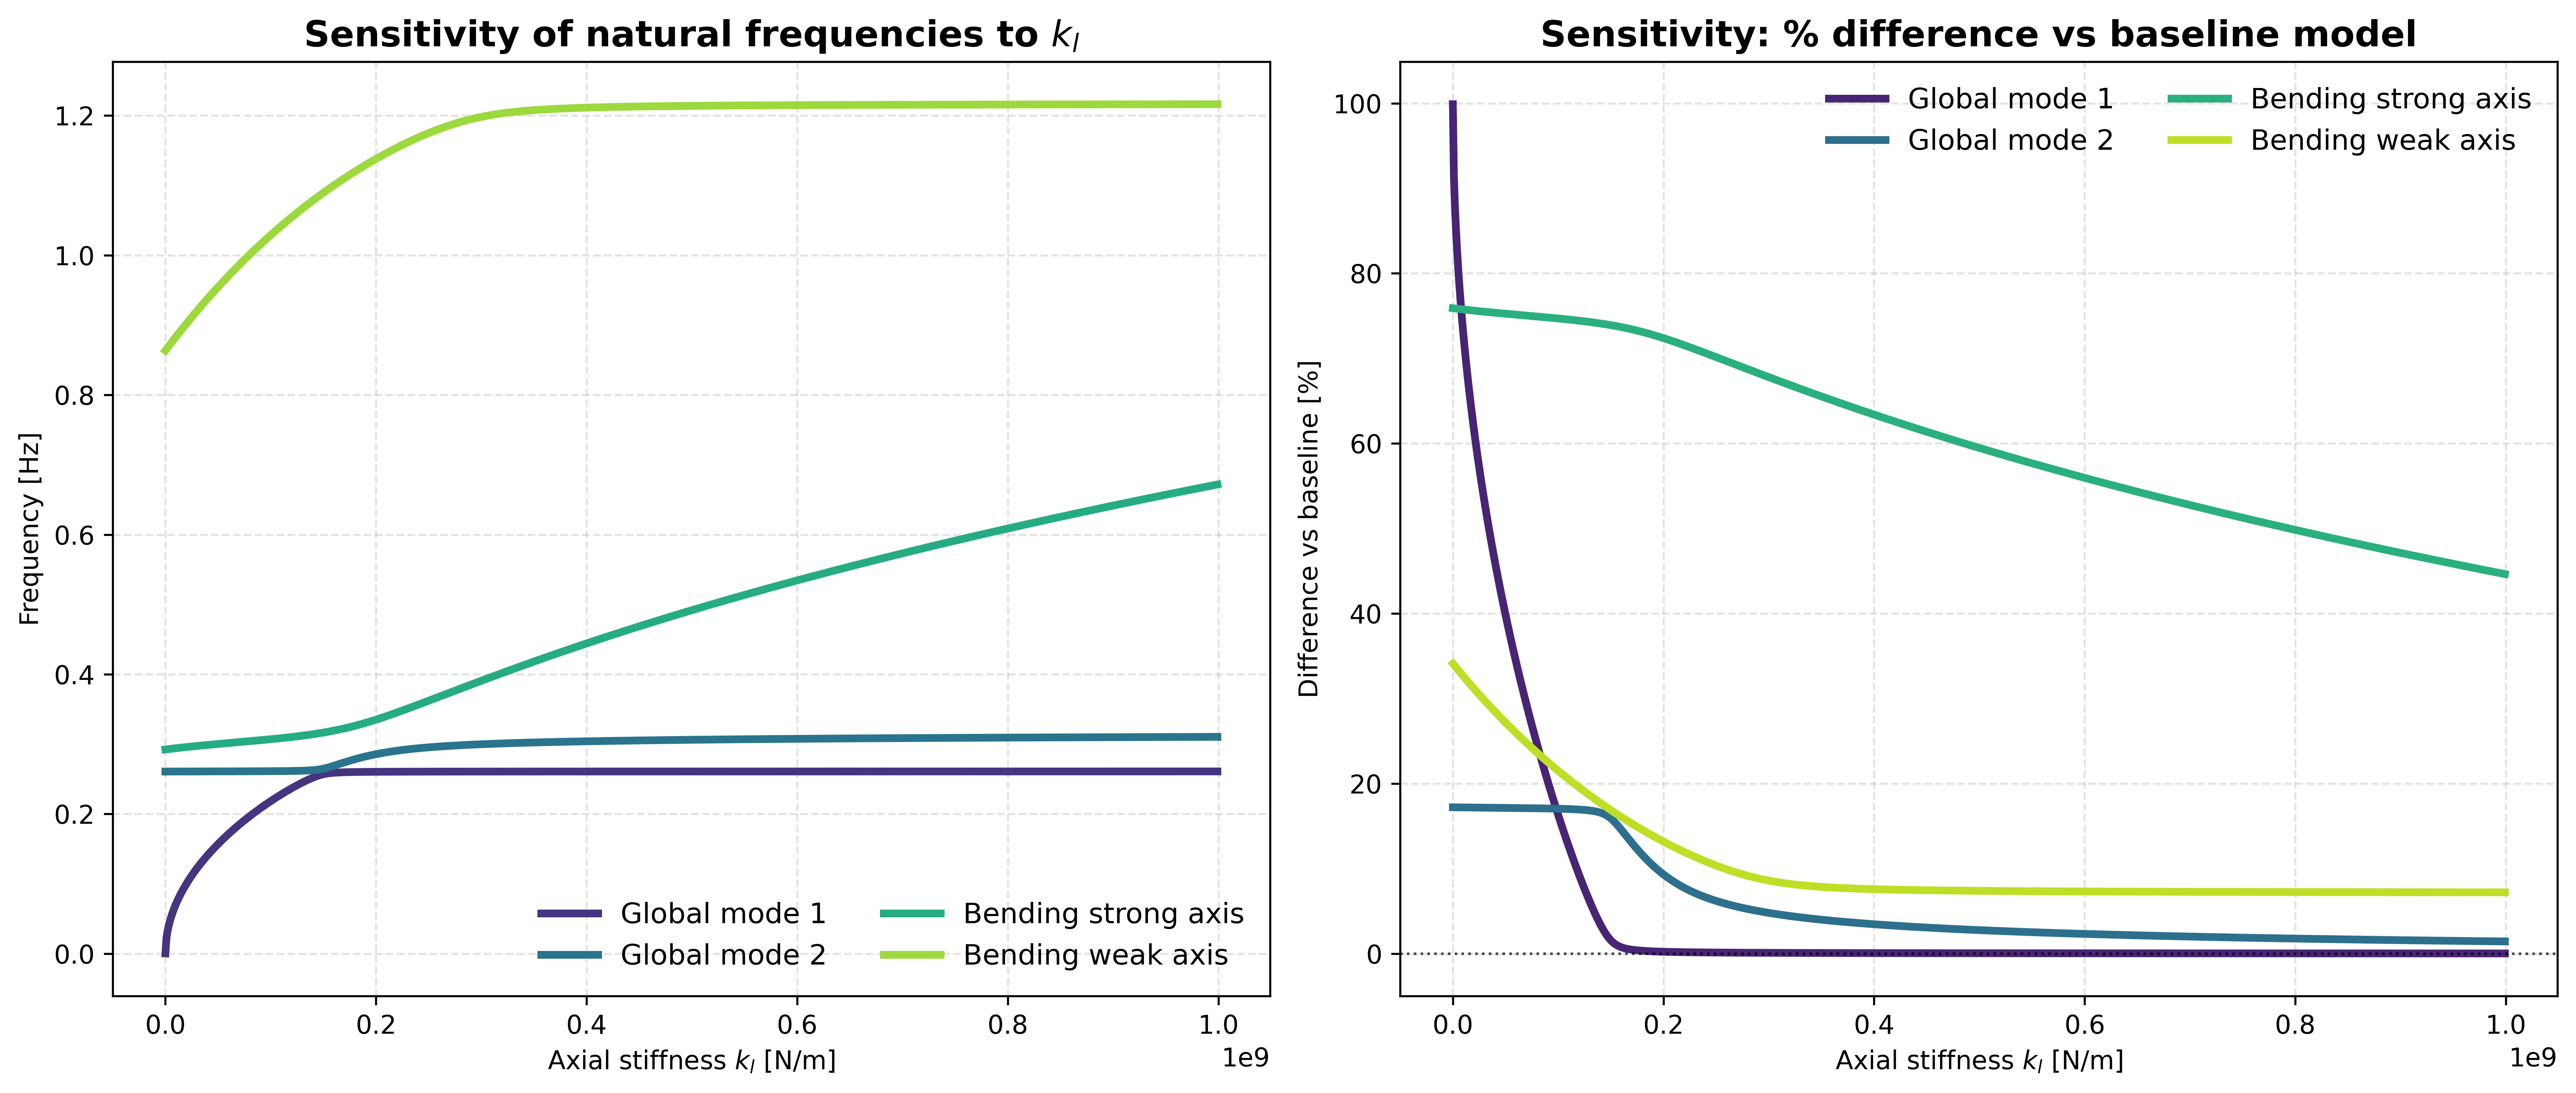

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=600)

# -------------------- LEFT: frequency sensitivity to kl --------------------
labels1 = ['Global mode 1', 'Global mode 2', 'Bending strong axis', 'Bending weak axis']
colors1 = plt.cm.viridis(np.linspace(0.15, 0.85, len(labels1)))

for i, (label, color) in enumerate(zip(labels1, colors1)):
    ax1.plot(kl, params[:, i], label=f'{label}', linewidth=3, color=color)

ax1.set_xlabel(r'Axial stiffness $k_l$ [N/m]')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_title('Sensitivity of natural frequencies to $k_l$', fontsize=14, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.35)
ax1.legend(frameon=False, ncol=2, fontsize=11)
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))


# -------------------- RIGHT: % difference vs baseline --------------------
labels2 = ['Global mode 1', 'Global mode 2', 'Bending strong axis', 'Bending weak axis']
series = [percent_diff_f1, percent_diff_f2, percent_diff_f3, percent_diff_f4]
colors2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(series)))

for y, label, color in zip(series, labels2, colors2):
    ax2.plot(kl, y, label=f'{label}', linewidth=3.0, color=color)

ax2.axhline(0, color='k', linewidth=1, linestyle=':', alpha=0.7)

ax2.set_xlabel(r'Axial stiffness $k_l$ [N/m]')
ax2.set_ylabel('Difference vs baseline [%]')
ax2.set_title('Sensitivity: % difference vs baseline model', fontsize=14, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.35)
ax2.legend(frameon=False, ncol=2, fontsize=11)
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.show()

# **MAC matrix plots**

In [16]:
eigvecs_baseline = np.load('../text_files/eigvecs_global.npy')

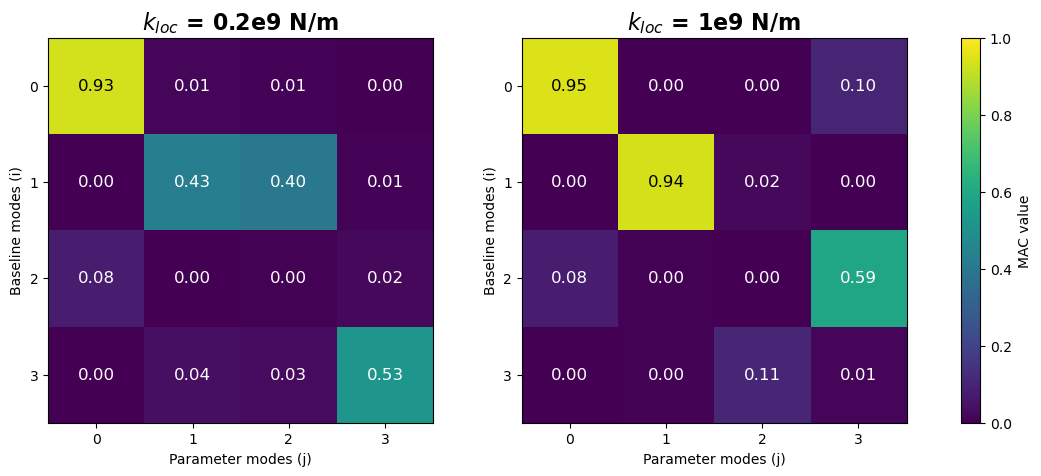

In [17]:
n = 4

# k_r values and corresponding indices
Iy_values = [0.2, 1]
indices = [200, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (Iy, ind) in enumerate(zip(Iy_values, indices)):

    MAC = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            phi_base = eigvecs_baseline[:, i]
            phi_param = eigvecs_params[ind][:, j]

            MAC[i, j] = (np.abs(phi_base.T @ phi_param)**2) / (
                (phi_base.T @ phi_base) * (phi_param.T @ phi_param)
            )

    ax = axes[idx]

    im = ax.imshow(MAC, cmap='viridis', vmin=0, vmax=1)

    # Titles & labels
    ax.set_title(f"$k_{{loc}}$ = {Iy}e9 N/m", fontsize=16, fontweight='bold')
    ax.set_xlabel("Parameter modes (j)")
    ax.set_ylabel("Baseline modes (i)")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    # -----------------------------
    # 🔥 Add text annotations
    # -----------------------------
    for i in range(n):
        for j in range(n):
            val = MAC[i, j]
            text_color = "white" if val < 0.6 else "black"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                color=text_color, fontsize=12
            )

# One shared colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), label='MAC value')
plt.show()
